# 03 · Harmful & Mixed Regimes + Statistical Rigor

Where adaptation is mostly harmful, KGA refuses it; in the mixed regime it discriminates per-instance.
All numbers loaded from real result artifacts; the mixed regime is repeated over 8 seeds with paired t-tests.


In [1]:
import os, json, glob, numpy as np
REPO=os.path.abspath(os.getcwd())
while REPO!='/' and not os.path.exists(os.path.join(REPO,'scripts','rebuild_kbound.sh')): REPO=os.path.dirname(REPO)
RES=os.path.join(REPO,'experiments','kbound','results'); FIG=os.path.join(REPO,'docs','research','kbound','figures')
ARCH=os.path.join(REPO,'experiments','elara_u','score_archive'); TV=os.path.join(REPO,'experiments','kbound','theory_validation')
from IPython.display import Image, display
def jload(p):
    fp=p if os.path.isabs(p) else os.path.join(RES,p)
    return json.load(open(fp)) if os.path.exists(fp) else {}
def fig(fn,w=720):
    p=os.path.join(FIG,fn)
    if os.path.exists(p): display(Image(filename=p,width=w))
print('repo:',REPO)

repo: /sessions/optimistic-amazing-ritchie/mnt/uav/AutoML_Flagship_V8


In [2]:
h=jload('kbound_harmful_results.json')
print('### Harmful fusion regime'); print(' mean_auc:',h.get('mean_auc')); print(' regret_vs_oracle:',h.get('regret_vs_oracle'))
m=jload('mixed_regime_results.json')
print('\n### Mixed regime'); print(' policies:',m.get('mean_auc_policies')); print(' safety:',m.get('safety'))
r=jload('rigor_multiseed.json')
print('\n### 8-seed rigor'); print(' mean_std:',{k:r['mean_std'][k] for k in ['always_adapt','always_freeze','K_Bound','oracle']})
print(' t vs freeze:',r.get('paired_ttest_KBound_vs_always_freeze')); print(' t vs adapt:',r.get('paired_ttest_KBound_vs_always_adapt'))

### Harmful fusion regime
 mean_auc: {'always_adapt(elara_fuse)': 0.7284284552845529, 'always_freeze(auto_select)': 0.7480577235772359, 'K-Bound_trichotomy': 0.7479455284552846, 'oracle': 0.7498634146341464}
 regret_vs_oracle: {'always_adapt': 0.0214349593495935, 'always_freeze': 0.0018056910569105692, 'K-Bound': 0.001917886178861789}

### Mixed regime
 policies: {'always_adapt': 0.6971114217409946, 'always_freeze': 0.5862362368571814, 'K_Bound': 0.6898522630259771, 'oracle': 0.7189128955491799}
 safety: {'adapt_precision_B>0': 0.9347826086956522, 'false_adapt_rate_B<0': 0.06521739130434782}

### 8-seed rigor
 mean_std: {'always_adapt': [0.6969783881179049, 8.399016284971985e-05], 'always_freeze': [0.5841853559610777, 0.0014670002792189914], 'K_Bound': [0.6859821592117441, 0.003336273617313085], 'oracle': [0.7180348491228252, 0.0006395177786479187]}
 t vs freeze: {'t': 62.235774407328385, 'p': 7.261976392007134e-11}
 t vs adapt: {'t': -8.75989045559896, 'p': 5.0842555812787246e-05}


## Mixed-regime policies and decisions


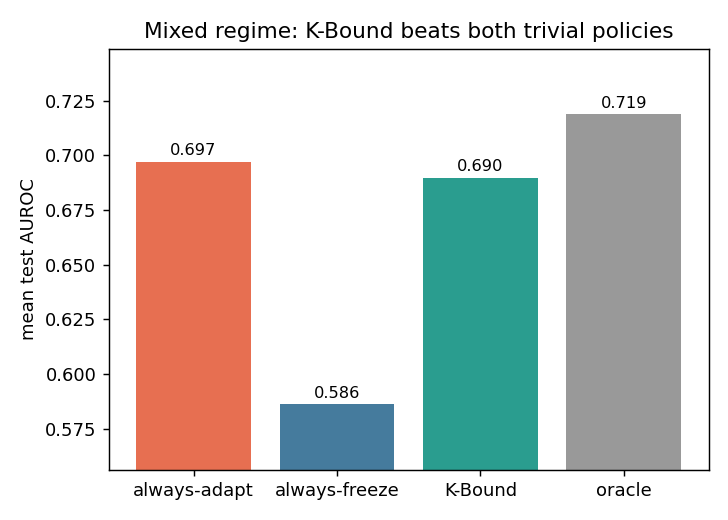

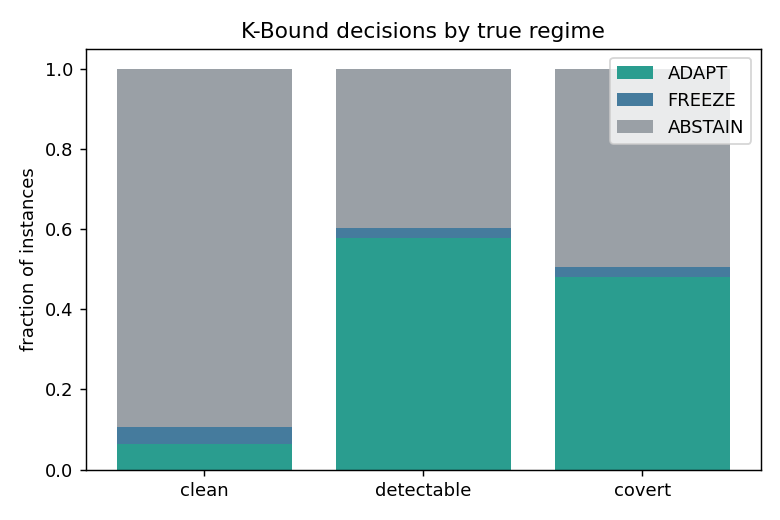

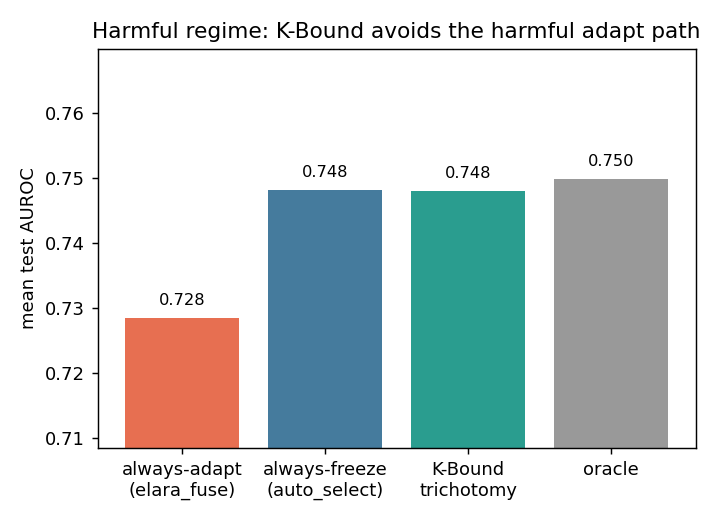

In [3]:
fig('fig_mixed_policies.png'); fig('fig_mixed_decisions.png'); fig('fig_kbound_harmful.png')